# MJ Barros Visualization (Notebook)

Notebook para carregar o CSV consolidado da MJ Barros, filtrar apenas \"Casa\" e \"Casa de Condominio\" e gerar grafico de dispersao com escala log-log (preco vs area), usando cor para separar categorias.

In [1]:
from pathlib import Path
import unicodedata

import pandas as pd

try:
    from plotnine import (
        ggplot, aes, geom_point, scale_x_log10, scale_y_log10, labs, theme_bw
    )
except Exception as exc:
    raise ImportError(
        "Pacote 'plotnine' nao encontrado. Instale com: pip install plotnine"
    ) from exc

In [ ]:
# Configuracao
CSV_DIR = Path('../data/processed/csv')
CSV_PATTERN = 'mjbarros_*.csv'

def find_latest_csv(csv_dir: Path = CSV_DIR, pattern: str = CSV_PATTERN) -> Path:
    files = sorted(csv_dir.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f'Nenhum CSV encontrado em: {csv_dir.resolve()}')
    return files[-1]

def load_csv(csv_file: Path) -> pd.DataFrame:
    if not csv_file.exists():
        raise FileNotFoundError(f'Arquivo CSV nao encontrado: {csv_file}')
    return pd.read_csv(csv_file, sep=';')

def normalize_text(value: str | None) -> str:
    if value is None:
        return ''
    text = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode('ascii')
    return text.strip().lower()

def classify_categoria(tipo: str | None) -> str | None:
    norm = normalize_text(tipo)
    if norm == 'casa':
        return 'Casa'
    if norm == 'casa de condominio':
        return 'Casa de Condominio'
    return None

In [ ]:
# Se quiser forcar um arquivo especifico, descomente e ajuste:
# csv_file = Path('../data/processed/csv/mjbarros_venda_2026-05-15.csv')

csv_file = find_latest_csv()
df = load_csv(csv_file)

print(f'CSV selecionado: {csv_file.resolve()}')
print(f'Linhas no CSV: {len(df)}')
df[['tipo', 'preco', 'area_m2']].head()

CSV selecionado: /home/walmes/Projects/UFPR_GenAI/DSLLM-02-web-scraping/output_csv/mjbarros/mjbarros_venda_2026-05-15.csv
Linhas no CSV: 431


,tipo,preco,area_m2
0,Apartamento,1480000.0,118.0
1,Casa de Condomínio,2300000.0,410.0
2,Casa,620000.0,123.0
3,Terreno,165900.0,200.0
4,Terreno,607000.0,434.0


In [4]:
# Filtro: apenas Casa e Casa de Condominio
plot_df = df.copy()
plot_df['categoria'] = plot_df['tipo'].apply(classify_categoria)
plot_df = plot_df[plot_df['categoria'].notna()].copy()

# Remocao de valores invalidos para escala log
plot_df = plot_df[(plot_df['preco'].notna()) & (plot_df['area_m2'].notna())]
plot_df = plot_df[(plot_df['preco'] > 0) & (plot_df['area_m2'] > 0)]

print(f'Linhas para plot: {len(plot_df)}')
print(plot_df['categoria'].value_counts(dropna=False))
plot_df[['tipo', 'categoria', 'preco', 'area_m2']].head()

Linhas para plot: 165
categoria
Casa                  113
Casa de Condominio     52
Name: count, dtype: int64


,tipo,categoria,preco,area_m2
1,Casa de Condomínio,Casa de Condominio,2300000.0,410.0
2,Casa,Casa,620000.0,123.0
6,Casa de Condomínio,Casa de Condominio,1700000.0,170.0
10,Casa,Casa,3390000.0,527.0
15,Casa,Casa,850000.0,134.0


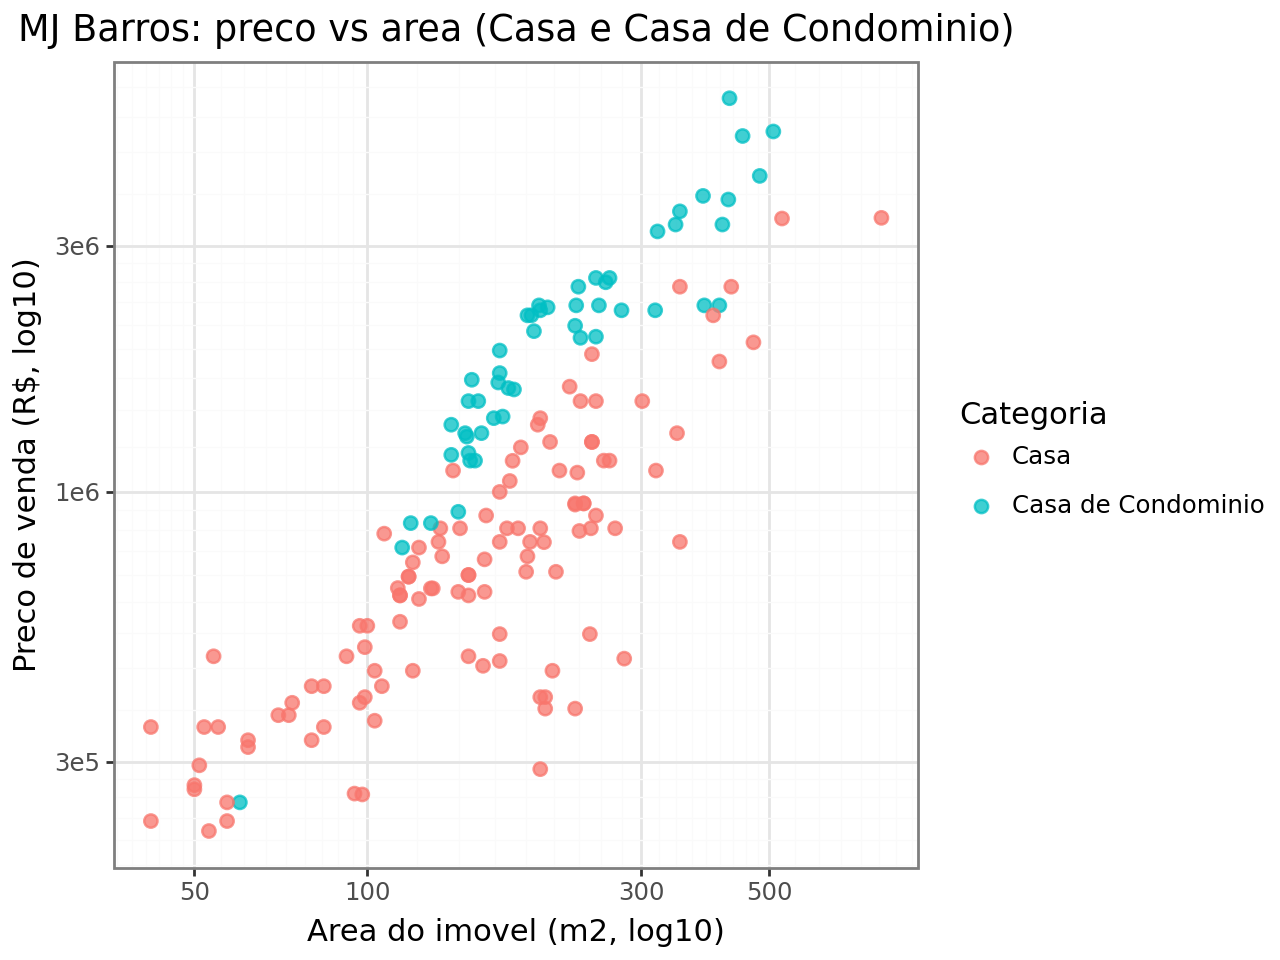

In [5]:
if plot_df.empty:
    raise RuntimeError('Nao ha dados de Casa/Casa de Condominio com preco e area positivos para gerar o grafico.')

plot_obj = (
    ggplot(plot_df, aes(x='area_m2', y='preco', color='categoria'))
    + geom_point(alpha=0.75, size=2.2)
    + scale_x_log10()
    + scale_y_log10()
    + labs(
        title='MJ Barros: preco vs area (Casa e Casa de Condominio)',
        x='Area do imovel (m2, log10)',
        y='Preco de venda (R$, log10)',
        color='Categoria'
    )
    + theme_bw()
)

plot_obj